In [2]:
import re
import pandas as pd
import sys
sys.path.append('/home/zxhuang/ugi/covalent_molecule_library')
from tqdm.auto import tqdm
from rdkit.Chem import PandasTools


In [3]:
from functional_group_utils import StrictCovalentWarHeadCounter, RelaxedCovalentWarHeadCounter
from rxn_utils import ugi_click_rxn, ugi_4c4c_rxn

## deal with azide

In [12]:
with open('azide.smi', 'r') as f:
    lines = f.readlines()
cnt = 0
for l in lines:
    if not re.findall(r'N\=\[N\+\]\=\[N-\]|\[N-\]\=\[N\+\]\=N', l.split()[0]):
        cnt += 1
        print(l.split()[0])
print(cnt)

C[C@H]([NH+]=[N+]=[N-])C1=CC=C(C2=CC=CC=C2)C=C1
CC(C)(C)[PH+](CC[NH+]=[N+]=[N-])C(C)(C)C
2


In [11]:
pattern = r'N\=\[N\+\]\=\[N-\]|\[N-\]\=\[N\+\]\=N'

# 测试字符串
test_string1 = 'N=[N+]=[N-]'
test_string2 = '[N-]=[N+]=N'

# 匹配
match1 = re.match(pattern, test_string1)
match2 = re.match(pattern, test_string2)

# 输出结果
print('Match 1:', match1 is not None)  # True
print('Match 2:', match2 is not None)  # True


Match 1: False
Match 2: True


## clean covalent warhead

In [3]:
strict_covalent_warhead_counter = StrictCovalentWarHeadCounter()
relaxed_covalent_warhead_counter = RelaxedCovalentWarHeadCounter()

In [13]:
# df = pd.read_csv('amine.smi', sep=' ', header=None)
# df = pd.read_csv('acid.smi', sep=' ', header=None)
# df = pd.read_csv('aldehyde.smi', sep=' ', header=None)
df = pd.read_csv('azide.smi', sep=' ', header=None)
df.columns = ['smiles', 'id']
for warhead in relaxed_covalent_warhead_counter.fg_dict:
    if warhead == 'aldehyde':
        continue
    df[warhead] = df['smiles'].apply(lambda x: relaxed_covalent_warhead_counter.count_fg(x, warhead))

In [14]:
df['warhead_cnt'] = df.iloc[:, 2:].sum(axis=1)
df

,smiles,id,acryloyl,cyano,fluorosulfonyl,alpha_cl_oxo,vinyl_sulfone,propynoyl,allenamide,isocyanate,strained_cyclobutane,expoxide_aziridine,NASA,boronic_acids,SnAr,warhead_cnt
0,[N-]=[N+]=NCCCO,bide-click-am-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,CCOC(=O)CN=[N+]=[N-],bide-click-am-2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,CCN=[N+]=[N-],bide-click-am-3,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,[N-]=[N+]=NCCBr,bide-click-am-4,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,COC(=O)CN=[N+]=[N-],bide-click-am-5,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2656,CC(C)(C)OC(=O)N1C2CCCC1C(N=[N+]=[N-])CC2,bide-click-am-2682,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2657,[N-]=[N+]=NC[C@]12COC[C@H]1C2,bide-click-am-2683,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2658,[N-]=[N+]=N[C@H]1C[C@@H](C(F)(F)F)C1,bide-click-am-2684,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2659,[N-]=[N+]=NCC1(C2=CC(C(F)(F)F)=CC=C2)CC1,bide-click-am-2685,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [15]:
df_ = df[df['warhead_cnt'] == 0]
df_ = df_[['smiles', 'id']]
# df_.to_csv('amine_no_warhead.smi', sep=' ', index=False, header=False)
# df_.to_csv('acid_no_warhead.smi', sep=' ', index=False, header=False)
# df_.to_csv('aldehyde_no_warhead.smi', sep=' ', index=False, header=False)
df_.to_csv('azide_no_warhead.smi', sep=' ', index=False, header=False)
df_.shape

(2525, 2)

## draw chemical space

In [4]:
import umap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns
from matplotlib import pyplot as plt

from molfeat.trans.fp import FPVecTransformer
from molfeat.calc.pharmacophore import Pharmacophore2D
from molfeat.trans.base import MoleculeTransformer

ecfp_transformer = FPVecTransformer(kind='ecfp-count', dtype=float, n_jobs=8, length=1024)
pmapper_transformer = MoleculeTransformer(featurizer=Pharmacophore2D(factory='pmapper'), dtype=float, n_jobs=8)


In [5]:
# random synthesis 3,000 ugi-click molecules with ace-on-(amine, acid, aldehyde)
dir_path = '/home/zxhuang/ugi/TS/data/ugi-click'
df_ace_on_amine = pd.read_csv(f'{dir_path}/BBs_with_ace/ace_on_amine.smi', sep=' ', header=None)
df_ace_on_amine.columns = ['smiles', 'id']
df_ace_on_acid = pd.read_csv(f'{dir_path}/BBs_with_ace/ace_on_acid.smi', sep=' ', header=None)
df_ace_on_acid.columns = ['smiles', 'id']
df_ace_on_aldehyde = pd.read_csv(f'{dir_path}/BBs_with_ace/ace_on_aldehyde.smi', sep=' ', header=None)
df_ace_on_aldehyde.columns = ['smiles', 'id']

df_acid = pd.read_csv(f'{dir_path}/BBs/acid_no_warhead.smi', sep=' ', header=None)
df_acid.columns = ['smiles', 'id']
df_amine = pd.read_csv(f'{dir_path}/BBs/amine_no_warhead.smi', sep=' ', header=None)
df_amine.columns = ['smiles', 'id']
df_aldehyde = pd.read_csv(f'{dir_path}/BBs/aldehyde_no_warhead.smi', sep=' ', header=None)
df_aldehyde.columns = ['smiles', 'id']
df_nc = pd.read_csv(f'{dir_path}/BBs/NC.smi', sep=' ', header=None)
df_nc.columns = ['smiles', 'id']
df_azide = pd.read_csv(f'{dir_path}/BBs/azide_no_warhead.smi', sep=' ', header=None)
df_azide.columns = ['smiles', 'id']

In [6]:
sample_num = 1000

df_ugi_click_sample = pd.DataFrame(columns=['id', 'smiles', 'source'])
for i in tqdm(range(sample_num), desc='ace_on_amine'):
    ace_on_amine_id, ace_on_amine_smiles = df_ace_on_amine.sample(1)['id'].values[0], df_ace_on_amine.sample(1)['smiles'].values[0]
    acid_id, acid_smiles = df_acid.sample(1)['id'].values[0], df_acid.sample(1)['smiles'].values[0]
    aldehyde_id, aldehyde_smiles = df_aldehyde.sample(1)['id'].values[0], df_aldehyde.sample(1)['smiles'].values[0]
    nc_id, nc_smiles = df_nc.sample(1)['id'].values[0], df_nc.sample(1)['smiles'].values[0]
    azide_id, azide_smiles = df_azide.sample(1)['id'].values[0], df_azide.sample(1)['smiles'].values[0]
    prod_smiles = ugi_click_rxn(
        acid_smi = acid_smiles,
        aldehyde_smi = aldehyde_smiles,
        nc_smi = nc_smiles,
        amine_smi = ace_on_amine_smiles,
        azide_smi = azide_smiles
    )
    prod_id = f'{acid_id}_{aldehyde_id}_{nc_id}_{ace_on_amine_id}_{azide_id}'
    # df_ugi_click_sample = pd.concat([df_ugi_click_sample, pd.DataFrame({'id': [prod_id], 'smiles': [prod_smiles], 'source': ['ace_on_amine']})], ignore_index=True)
    df_ugi_click_sample = pd.concat([df_ugi_click_sample, pd.DataFrame({'id': [prod_id], 'smiles': [prod_smiles], 'source': ['ugi-click']})], ignore_index=True)

for i in tqdm(range(sample_num), desc='ace_on_acid'):
    ace_on_acid_id, ace_on_acid_smiles = df_ace_on_acid.sample(1)['id'].values[0], df_ace_on_acid.sample(1)['smiles'].values[0]
    amine_id, amine_smiles = df_amine.sample(1)['id'].values[0], df_amine.sample(1)['smiles'].values[0]
    aldehyde_id, aldehyde_smiles = df_aldehyde.sample(1)['id'].values[0], df_aldehyde.sample(1)['smiles'].values[0]
    nc_id, nc_smiles = df_nc.sample(1)['id'].values[0], df_nc.sample(1)['smiles'].values[0]
    azide_id, azide_smiles = df_azide.sample(1)['id'].values[0], df_azide.sample(1)['smiles'].values[0]
    prod_smiles = ugi_click_rxn(
        acid_smi = ace_on_acid_smiles,
        aldehyde_smi = aldehyde_smiles,
        nc_smi = nc_smiles,
        amine_smi = amine_smiles,
        azide_smi = azide_smiles
    )
    prod_id = f'{ace_on_acid_id}_{aldehyde_id}_{nc_id}_{amine_id}_{azide_id}'
    # df_ugi_click_sample = pd.concat([df_ugi_click_sample, pd.DataFrame({'id': [prod_id], 'smiles': [prod_smiles], 'source': ['ace_on_acid']})], ignore_index=True)
    df_ugi_click_sample = pd.concat([df_ugi_click_sample, pd.DataFrame({'id': [prod_id], 'smiles': [prod_smiles], 'source': ['ugi-click']})], ignore_index=True)

for i in tqdm(range(sample_num), desc='ace_on_aldehyde'):
    ace_on_aldehyde_id, ace_on_aldehyde_smiles = df_ace_on_aldehyde.sample(1)['id'].values[0], df_ace_on_aldehyde.sample(1)['smiles'].values[0]
    amine_id, amine_smiles = df_amine.sample(1)['id'].values[0], df_amine.sample(1)['smiles'].values[0]
    acid_id, acid_smiles = df_acid.sample(1)['id'].values[0], df_acid.sample(1)['smiles'].values[0]
    nc_id, nc_smiles = df_nc.sample(1)['id'].values[0], df_nc.sample(1)['smiles'].values[0]
    azide_id, azide_smiles = df_azide.sample(1)['id'].values[0], df_azide.sample(1)['smiles'].values[0]
    prod_smiles = ugi_click_rxn(
        acid_smi = acid_smiles,
        aldehyde_smi = ace_on_aldehyde_smiles,
        nc_smi = nc_smiles,
        amine_smi = amine_smiles,
        azide_smi = azide_smiles
    )
    prod_id = f'{acid_id}_{ace_on_aldehyde_id}_{nc_id}_{amine_id}_{azide_id}'
    # df_ugi_click_sample = pd.concat([df_ugi_click_sample, pd.DataFrame({'id': [prod_id], 'smiles': [prod_smiles], 'source': ['ace_on_aldehyde']})], ignore_index=True)
    df_ugi_click_sample = pd.concat([df_ugi_click_sample, pd.DataFrame({'id': [prod_id], 'smiles': [prod_smiles], 'source': ['ugi-click']})], ignore_index=True)

df_ugi_click_sample


ace_on_amine:   0%|          | 0/1000 [00:00<?, ?it/s]

ace_on_acid:   0%|          | 0/1000 [00:00<?, ?it/s]

ace_on_aldehyde:   0%|          | 0/1000 [00:00<?, ?it/s]

,id,smiles,source
0,bide-uc-546_bide-uc-5354_bide-uc-1858_bide-uc-...,COC1=C(C(=O)N(C2=CC=CC=C2C2=CN([C@@H]3CCCN(C(=...,ugi-click
1,bide-uc-1304_bide-uc-1863_bide-uc-1140_bide-uc...,C[C@@H](N1C=C(C2=CC(N(C(=O)C3=CC=CC4=C3SC=N4)C...,ugi-click
2,bide-uc-1527_bide-uc-2629_bide-uc-1140_bide-uc...,CC(C)(C)NC(=O)C(C1=CC(F)=C(Cl)C=C1F)N(C(=O)C[C...,ugi-click
3,bide-uc-4489_bide-uc-2923_bide-uc-1140_bide-uc...,COC1=CC(CN2C=C(CN(C(=O)C3=CC=C(C)C=C3OC)C(C(=O...,ugi-click
4,bide-uc-592_bide-uc-1849_bide-uc-1858_bide-uc-...,CN1C=CC2=CC=C(C(C(=O)NCC3=CC=CC=C3)N(CC3=CN([C...,ugi-click
...,...,...,...
2995,bide-uc-3139_bide-uc-1890_bide-uc-1858_bide-uc...,COC1=CC(Br)=C(OC)C(N(C(=O)CC2=CC=CC3=C2C=CN3)C...,ugi-click
2996,bide-uc-5275_bide-uc-1890_bide-uc-1140_bide-uc...,C=CC1=CC=C(N(C(=O)C2=CC=C3C=NN(C)C3=C2)C(C(=O)...,ugi-click
2997,bide-uc-597_bide-uc-1659_bide-uc-1858_bide-uc-...,COC(=O)C(N1C=C(C2=CC=C(C(C(=O)NC(C)(C)C)N(C(=O...,ugi-click
2998,bide-uc-3557_bide-uc-1890_bide-uc-1140_bide-uc...,C[C@H](C1=CN=CC=C1)N1C=C(C2=CC=CC=C2C(C(=O)NC(...,ugi-click


In [8]:
sample_num = 3000
df_ugi_sample = pd.DataFrame(columns=['id', 'smiles', 'source'])
for i in tqdm(range(sample_num), desc='acid'):
    acid_id, acid_smiles = df_acid.sample(1)['id'].values[0], df_acid.sample(1)['smiles'].values[0]
    amine_id, amine_smiles = df_amine.sample(1)['id'].values[0], df_amine.sample(1)['smiles'].values[0]
    aldehyde_id, aldehyde_smiles = df_aldehyde.sample(1)['id'].values[0], df_aldehyde.sample(1)['smiles'].values[0]
    nc_id, nc_smiles = df_nc.sample(1)['id'].values[0], df_nc.sample(1)['smiles'].values[0]
    prod_smiles = ugi_4c4c_rxn(
        acid_smi = acid_smiles,
        aldehyde_smi = aldehyde_smiles,
        nc_smi = nc_smiles,
        amine_smi = amine_smiles,
    )
    prod_id = f'{acid_id}_{aldehyde_id}_{nc_id}_{amine_id}_{azide_id}'
    df_ugi_sample = pd.concat([df_ugi_sample, pd.DataFrame({'id': [prod_id], 'smiles': [prod_smiles], 'source': ['ugi']})], ignore_index=True)

acid:   0%|          | 0/3000 [00:00<?, ?it/s]

In [9]:
enamine_data_path = '/home/zxhuang/modular_click/virtual_reagents/Enamine/previous/Enamine_2022_sampled_data.csv'
df_enamine = pd.read_csv(enamine_data_path)
df_enamine['source'] = 'Enamine-REAL'
df_enamine.rename(columns={'idnumber': 'id'}, inplace=True)
df_enamine

,smiles,id,source
0,COC1=CC(F)=C(C(=O)NC(C)(C)CCCNC(=O)OC(C)(C)C)C...,Z3085457096,Enamine-REAL
1,CC(C)CN1CCC(C(=O)N2CCN(C3=CC(C(F)(F)F)=NC=N3)C...,Z4424227820,Enamine-REAL
2,COC1=CC=C2C=CC=C(CC(=O)N=S3(=O)CCCC4(C3)OCCO4)...,Z3640991685,Enamine-REAL
3,O=C(CN1CCN(C(=O)C2=CC=NN2CC(F)(F)F)CC1)N1CCCCC1,Z2254355142,Enamine-REAL
4,CCOC(=O)C1=CC2=CC=CC(C(=O)N(CC3CCOCC3)C3CC3)=C2N1,Z5249274034,Enamine-REAL
...,...,...,...
110135,O=C(CC1(O)CCCCC1)NC1=CC=CC=C1CC1=CC=CC=C1,Z1203506945,Enamine-REAL
110136,CC1(C)CC(CO)CN(C(=O)C2CCC(OCC3CCC3)CC2)C1,Z4027139019,Enamine-REAL
110137,O=C(NC1=CC=C(OCC2=CC=CC=N2)C(F)=C1)C1=CN=C(S)N1,Z1739016667,Enamine-REAL
110138,CC(=O)C1=CC=C(NC(=O)C(=O)NC2CCC(=O)NC2(C)C)C=C1,Z2023411353,Enamine-REAL


In [10]:
chemdiv_data_path = '/home/zxhuang/modular_click/virtual_reagents/chemdiv/csv/chemdiv_total.csv'
df_chemdiv = pd.read_csv(chemdiv_data_path)
df_chemdiv['source'] = 'Chemdiv'
df_chemdiv

,id,smiles,source
0,K780-0323,CC(=O)Nc1cc(C(=O)O)ccc1Sc1ccc(C)cc1C,Chemdiv
1,K780-0325,COc1cc(Br)cc(C=O)c1O,Chemdiv
2,K780-0331,Cc1cc(Cl)n2nc(C)c(-c3ccc(Cl)cc3)c2n1,Chemdiv
3,K780-0360,Cc1cccc(-c2nc(CCl)c(C)o2)c1,Chemdiv
4,K780-0366,CCCC(=O)Nc1cc(C(=O)O)ccc1Sc1ccccc1,Chemdiv
...,...,...,...
1661833,K780-0312,COC(=O)c1ccc(Sc2ccccc2)c([N+](=O)[O-])c1,Chemdiv
1661834,K780-0317,CC(=O)Oc1ccc2c(C)cc(=O)oc2c1,Chemdiv
1661835,K780-0318,Cc1nc(N)[nH]c(=O)c1CCO,Chemdiv
1661836,K780-0319,CCOC(=O)/C(Cl)=C(/C)Nc1ccccc1N,Chemdiv


In [11]:
click_data_path = '/home/zxhuang/modular_click/virtual_reagents/triazole_sele.csv'
df_click = pd.read_csv(click_data_path)
df_click['source'] = 'click'
df_click.rename(columns={'mol_id': 'id', 'triazole_smi': 'smiles'}, inplace=True)
df_click = df_click[['id', 'smiles', 'source']]
df_click

,id,smiles,source
0,n1-a2,COC(=O)C(Cc1cn(CC(=O)N2CCCC2)nn1)NC(=O)OC(C)(C)C,click
1,n1-a4,CC(C)CC(C)(O)c1cn(CC(=O)N2CCCC2)nn1,click
2,n1-a5,CC(C)=CCCC(C)(O)c1cn(CC(=O)N2CCCC2)nn1,click
3,n1-a21,O=C(Cn1cc(-c2ccc(CO)cc2)nn1)N1CCCC1,click
4,n1-a22,O=C(Cn1cc(-c2ccc(O)cc2)nn1)N1CCCC1,click
...,...,...,...
1915582,n6366-a605,CC(=O)NCc1cn(C2(c3ccc(C(F)(F)F)cc3)CC2)nn1,click
1915583,n6366-a608,Nc1ccc(-c2cn(C3(c4ccc(C(F)(F)F)cc4)CC3)nn2)c(C...,click
1915584,n6366-a613,Nc1cnc(-c2cn(C3(c4ccc(C(F)(F)F)cc4)CC3)nn2)cn1,click
1915585,n6366-a615,Oc1ccc(-c2ccc(-c3cn(C4(c5ccc(C(F)(F)F)cc5)CC4)...,click


In [12]:
known_3cl_inhibitor_data_path = '/home/zxhuang/modular_click/machine_learning/known_inhibitors.csv'
df_known_3cl_inhibitor = pd.read_csv(known_3cl_inhibitor_data_path)
df_known_3cl_inhibitor['source'] = '3CL_inhibitor'
df_known_3cl_inhibitor.rename(columns={'mol_id': 'id'}, inplace=True)
df_known_3cl_inhibitor = df_known_3cl_inhibitor[['id', 'smiles', 'source']]
df_known_3cl_inhibitor

,id,smiles,source
0,WIL-UNI-1faa9b10-57,O=C(O)C1=CC(S(=O)(=O)NC2=CC=C3OC(=O)NC3=C2)=CC...,3CL_inhibitor
1,WIL-UNI-1faa9b10-56,O=C(CNC(=O)C1=CC=C(F)C=C1)NC1=CC=C2NC(=O)NC2=C1,3CL_inhibitor
2,WIL-UNI-1faa9b10-55,NC(=O)C1=CC(C(=O)NCC2CCCN2C(=O)C2=CC=NC=C2)=CN1,3CL_inhibitor
3,WIL-UNI-1faa9b10-54,CN(CCNC(=O)C1=NOC=C1)C(=O)C1=CC=C(C(N)=O)N=C1,3CL_inhibitor
4,WIL-UNI-1faa9b10-53,O=S(=O)(NCC(O)C1=CC=C(F)C=C1)C1=CNC2=NC=CC(Cl)...,3CL_inhibitor
...,...,...,...
1880,DAR-DIA-23aa0b97-20,O=C(CC1=CN=CC2=CC=CC=C12)NC1=CC=CC=C1,3CL_inhibitor
1881,CHR-SOS-7098f804-14,O=C(NC1=CC=CN=C1)C1=CC(Cl)=CC=C1C1=CC=CC=C1,3CL_inhibitor
1882,CHR-SOS-7098f804-10,O=C(NC1=CN=CC=C1Cl)C1=CC(Cl)=CC=C1O,3CL_inhibitor
1883,BAR-COM-4e090d3a-6,CN1N=NC=C1CC(=O)NC(C1=CC=CC=C1)C1=NC2=CC=CC=C2N1C,3CL_inhibitor


### Chemdiv based

In [13]:
sample_num = 3000
random_seed = 1234
df_chemdiv_sampled = df_chemdiv.sample(sample_num, random_state=random_seed)


In [16]:
umap_transformer = umap.UMAP(n_components=2)
X_ecfp = ecfp_transformer(df_chemdiv_sampled['smiles'])
X_ecfp_umap = umap_transformer.fit_transform(X_ecfp)
df_chemdiv_sampled['ECFP_UMAP1'] = X_ecfp_umap[:, 0]
df_chemdiv_sampled['ECFP_UMAP2'] = X_ecfp_umap[:, 1]

<Axes: xlabel='ECFP_UMAP1', ylabel='ECFP_UMAP2'>

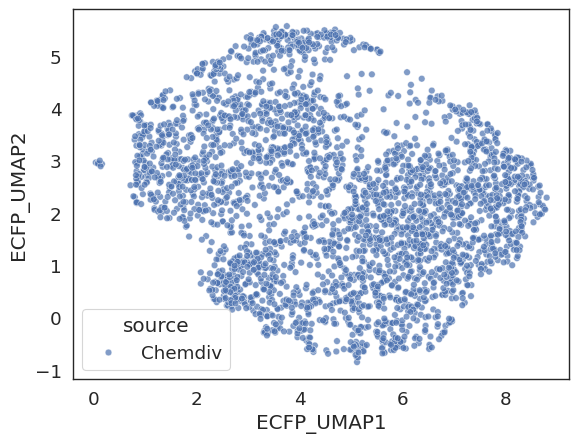

In [17]:
sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.5)
sns.scatterplot(data=df_chemdiv_sampled, x='ECFP_UMAP1', y='ECFP_UMAP2', hue='source', alpha=0.7)

In [18]:
tsne_transformer = TSNE(n_components=2)
X_ecfp = ecfp_transformer(df_chemdiv_sampled['smiles'])
X_ecfp_tsne = tsne_transformer.fit_transform(X_ecfp)
df_chemdiv_sampled['ECFP_TSNE1'] = X_ecfp_tsne[:, 0]
df_chemdiv_sampled['ECFP_TSNE2'] = X_ecfp_tsne[:, 1]

<Axes: xlabel='ECFP_TSNE1', ylabel='ECFP_TSNE2'>

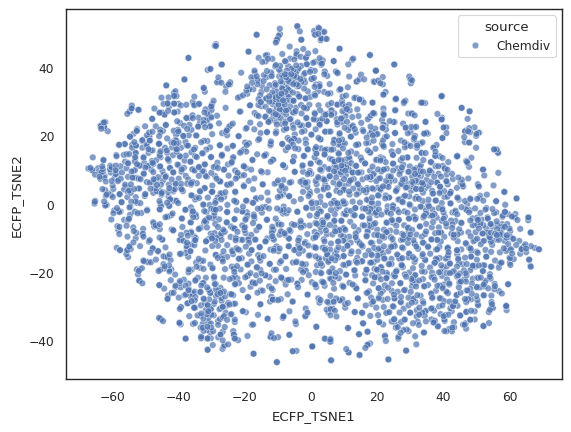

In [19]:
sns.set_theme(style="white")
sns.set_context("paper", font_scale=1)
sns.scatterplot(data=df_chemdiv_sampled, x='ECFP_TSNE1', y='ECFP_TSNE2', hue='source', alpha=0.7)

In [20]:
df_click_sampled = df_click.sample(sample_num, random_state=random_seed)
df_known_3cl_inhibitor_sampled = df_known_3cl_inhibitor.sample(frac=1, random_state=random_seed)
X_ecfp = ecfp_transformer(df_click_sampled['smiles'])
X_ecfp_umap = umap_transformer.transform(X_ecfp)
df_click_sampled['ECFP_UMAP1'] = X_ecfp_umap[:, 0]
df_click_sampled['ECFP_UMAP2'] = X_ecfp_umap[:, 1]
X_ecfp = ecfp_transformer(df_known_3cl_inhibitor_sampled['smiles'])
X_ecfp_tsne = umap_transformer.transform(X_ecfp)
df_known_3cl_inhibitor_sampled['ECFP_UMAP1'] = X_ecfp_tsne[:, 0]
df_known_3cl_inhibitor_sampled['ECFP_UMAP2'] = X_ecfp_tsne[:, 1]
df_merged = pd.concat([df_chemdiv_sampled, df_click_sampled, df_known_3cl_inhibitor_sampled], ignore_index=True)


<Axes: xlabel='ECFP_UMAP1', ylabel='ECFP_UMAP2'>

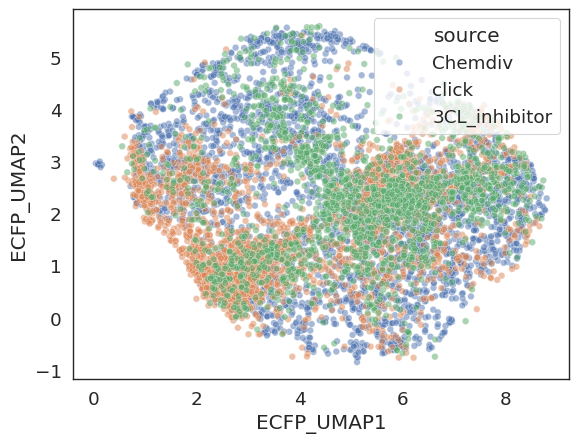

In [21]:
sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.5)
sns.scatterplot(data=df_merged, x='ECFP_UMAP1', y='ECFP_UMAP2', hue='source', alpha=0.5, legend='brief')


In [22]:
X_ecfp = ecfp_transformer(df_ugi_sample['smiles'])
X_ecfp_umap = umap_transformer.transform(X_ecfp)
df_ugi_sample['ECFP_UMAP1'] = X_ecfp_umap[:, 0]
df_ugi_sample['ECFP_UMAP2'] = X_ecfp_umap[:, 1]
df_merged = pd.concat([df_chemdiv_sampled, df_ugi_sample], ignore_index=True)


In [23]:
df_merged

,id,smiles,source,ecfp_umap1,ecfp_umap2,ECFP_UMAP1,ECFP_UMAP2,ECFP_TSNE1,ECFP_TSNE2
0,IB05-1100,c1cc2c(cc1-c1nn3c(CN4CCCCC4)nnc3s1)OCO2,Chemdiv,2.454131,2.571915,1.758816,3.787075,-52.968456,1.937435
1,8004-7962,Cc1ccc2nc(/C(C#N)=C/c3ccc(-c4ccc([N+](=O)[O-])...,Chemdiv,8.211950,2.588522,7.003785,1.514344,36.377571,-10.389100
2,L455-0104,CCOc1ccccc1NC(=O)c1ccc2c(c1)nnn2Cc1ccc(OC)cc1,Chemdiv,8.994021,3.520884,8.096424,1.933849,36.653599,-30.586634
3,Y205-7185,CC1CCC(NS(=O)(=O)c2ccc(Cl)s2)CC1,Chemdiv,2.962068,1.546192,1.614940,2.598838,-39.288490,16.410110
4,G300-0829,O=C(Cn1c2c(c(=O)n1-c1ccccc1)Cc1ccccc1O2)Nc1ccc...,Chemdiv,8.171410,5.091825,7.648057,3.699080,59.578129,-3.003091
...,...,...,...,...,...,...,...,...,...
5995,bide-uc-3406_bide-uc-1963_bide-uc-1858_bide-uc...,CC(C)(C)NC(=O)C(C1=CC(Cl)=C(O)C=C1O)N(C(=O)C1=...,ugi,NaN,NaN,3.216891,4.420153,NaN,NaN
5996,bide-uc-993_bide-uc-766_bide-uc-1140_bide-uc-4...,CC1=CC=C(C(F)(F)F)C=C1C(C(=O)NCC1=CC=CC=C1)N(C...,ugi,NaN,NaN,6.914298,2.599296,NaN,NaN
5997,bide-uc-2155_bide-uc-423_bide-uc-1858_bide-uc-...,COC1=CC(C(C(=O)NC(C)(C)C)N(C(=O)C2CC(=O)N(C3=C...,ugi,NaN,NaN,7.061061,1.904583,NaN,NaN
5998,bide-uc-532_bide-uc-3921_bide-uc-1140_bide-uc-...,COC1=CC=C(C(C(=O)NC(C)(C)C)N(C(=O)C2=C(C)N=C(C...,ugi,NaN,NaN,3.996212,1.963097,NaN,NaN


<Axes: xlabel='ECFP_UMAP1', ylabel='ECFP_UMAP2'>

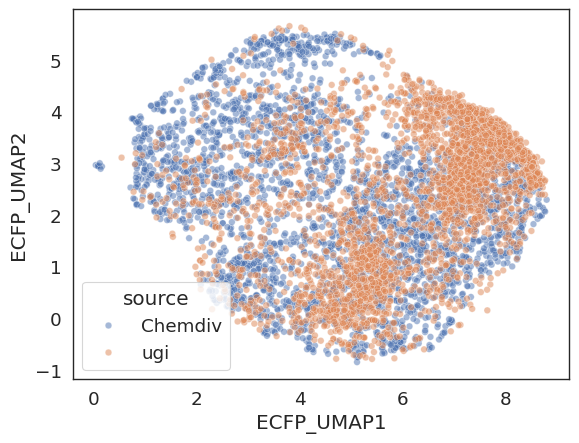

In [24]:
sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.5)
sns.scatterplot(data=df_merged, x='ECFP_UMAP1', y='ECFP_UMAP2', hue='source', alpha=0.5)


In [28]:
X_ecfp = ecfp_transformer(df_ugi_click_sample['smiles'])
X_ecfp_umap = umap_transformer.transform(X_ecfp)
df_ugi_click_sample['ECFP_UMAP1'] = X_ecfp_umap[:, 0]
df_ugi_click_sample['ECFP_UMAP2'] = X_ecfp_umap[:, 1]
df_merged = pd.concat([df_chemdiv_sampled, df_ugi_click_sample], ignore_index=True)

In [29]:
df_merged

,id,smiles,source,ecfp_umap1,ecfp_umap2,ECFP_UMAP1,ECFP_UMAP2,ECFP_TSNE1,ECFP_TSNE2
0,IB05-1100,c1cc2c(cc1-c1nn3c(CN4CCCCC4)nnc3s1)OCO2,Chemdiv,2.454131,2.571915,1.758816,3.787075,-52.968456,1.937435
1,8004-7962,Cc1ccc2nc(/C(C#N)=C/c3ccc(-c4ccc([N+](=O)[O-])...,Chemdiv,8.211950,2.588522,7.003785,1.514344,36.377571,-10.389100
2,L455-0104,CCOc1ccccc1NC(=O)c1ccc2c(c1)nnn2Cc1ccc(OC)cc1,Chemdiv,8.994021,3.520884,8.096424,1.933849,36.653599,-30.586634
3,Y205-7185,CC1CCC(NS(=O)(=O)c2ccc(Cl)s2)CC1,Chemdiv,2.962068,1.546192,1.614940,2.598838,-39.288490,16.410110
4,G300-0829,O=C(Cn1c2c(c(=O)n1-c1ccccc1)Cc1ccccc1O2)Nc1ccc...,Chemdiv,8.171410,5.091825,7.648057,3.699080,59.578129,-3.003091
...,...,...,...,...,...,...,...,...,...
5995,bide-uc-3139_bide-uc-1890_bide-uc-1858_bide-uc...,COC1=CC(Br)=C(OC)C(N(C(=O)CC2=CC=CC3=C2C=CN3)C...,ugi-click,NaN,NaN,7.804651,1.093384,NaN,NaN
5996,bide-uc-5275_bide-uc-1890_bide-uc-1140_bide-uc...,C=CC1=CC=C(N(C(=O)C2=CC=C3C=NN(C)C3=C2)C(C(=O)...,ugi-click,NaN,NaN,8.606885,2.798151,NaN,NaN
5997,bide-uc-597_bide-uc-1659_bide-uc-1858_bide-uc-...,COC(=O)C(N1C=C(C2=CC=C(C(C(=O)NC(C)(C)C)N(C(=O...,ugi-click,NaN,NaN,7.870210,1.646891,NaN,NaN
5998,bide-uc-3557_bide-uc-1890_bide-uc-1140_bide-uc...,C[C@H](C1=CN=CC=C1)N1C=C(C2=CC=CC=C2C(C(=O)NC(...,ugi-click,NaN,NaN,7.329895,3.018286,NaN,NaN


<Axes: xlabel='ECFP_UMAP1', ylabel='ECFP_UMAP2'>

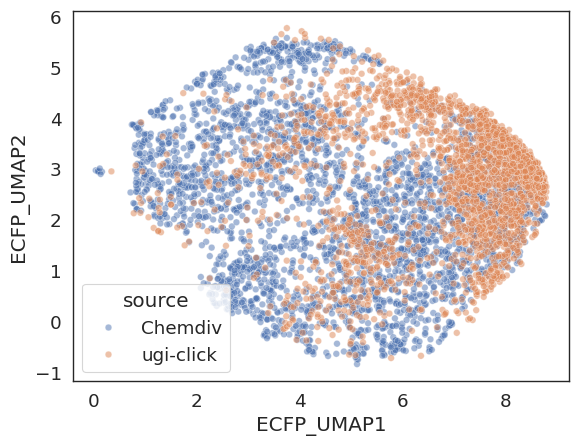

In [37]:
sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.5)
sns.scatterplot(data=df_merged, x='ECFP_UMAP1', y='ECFP_UMAP2', hue='source', alpha=0.5)

<Axes: xlabel='PMapper_UMAP1', ylabel='PMapper_UMAP2'>

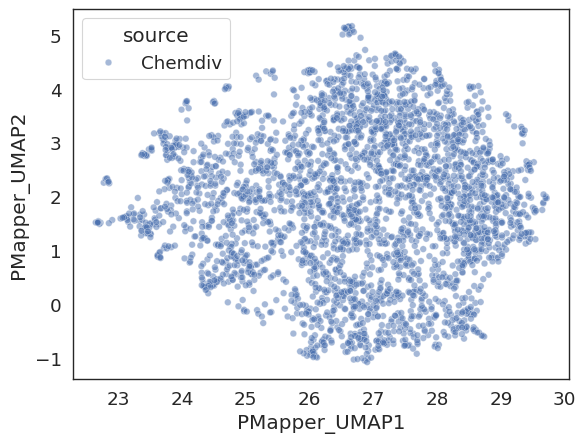

In [31]:
umap_transformer = umap.UMAP(n_components=2)
X_pmapper = pmapper_transformer(df_chemdiv_sampled['smiles'])
X_pmapper_umap = umap_transformer.fit_transform(X_pmapper)
df_chemdiv_sampled['PMapper_UMAP1'] = X_pmapper_umap[:, 0]
df_chemdiv_sampled['PMapper_UMAP2'] = X_pmapper_umap[:, 1]

sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.5)
sns.scatterplot(data=df_chemdiv_sampled, x='PMapper_UMAP1', y='PMapper_UMAP2', hue='source', alpha=0.5)

In [32]:
df_click_sampled = df_click.sample(sample_num, random_state=random_seed)
df_known_3cl_inhibitor_sampled = df_known_3cl_inhibitor.sample(frac=1, random_state=random_seed)
X_pmapper = pmapper_transformer(df_click_sampled['smiles'])
X_pmapper_umap = umap_transformer.transform(X_pmapper)
df_click_sampled['PMapper_UMAP1'] = X_pmapper_umap[:, 0]
df_click_sampled['PMapper_UMAP2'] = X_pmapper_umap[:, 1]
X_pmapper = pmapper_transformer(df_known_3cl_inhibitor_sampled['smiles'])
X_pmapper_tsne = umap_transformer.transform(X_pmapper)
df_known_3cl_inhibitor_sampled['PMapper_UMAP1'] = X_pmapper_tsne[:, 0]
df_known_3cl_inhibitor_sampled['PMapper_UMAP2'] = X_pmapper_tsne[:, 1]
df_merged = pd.concat([df_chemdiv_sampled, df_click_sampled, df_known_3cl_inhibitor_sampled], ignore_index=True)

<Axes: xlabel='PMapper_UMAP1', ylabel='PMapper_UMAP2'>

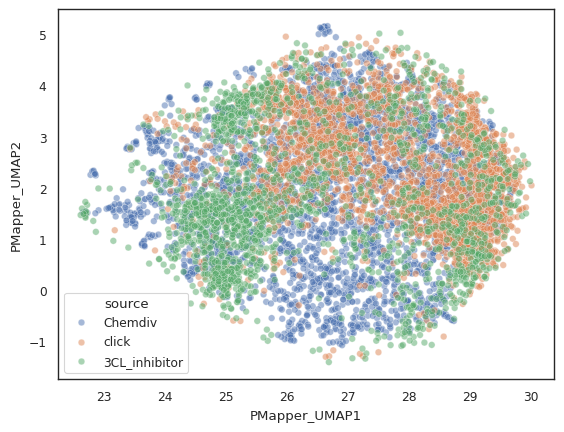

In [33]:
sns.set_theme(style="white")
sns.set_context("paper", font_scale=1)
sns.scatterplot(data=df_merged, x='PMapper_UMAP1', y='PMapper_UMAP2', hue='source', alpha=0.5, legend='brief')

<Axes: xlabel='PMapper_UMAP1', ylabel='PMapper_UMAP2'>

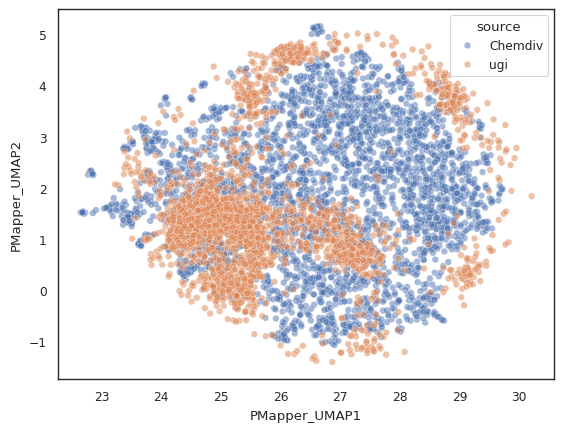

In [34]:
X_pmapper = pmapper_transformer(df_ugi_sample['smiles'])
X_pmapper_umap = umap_transformer.transform(X_pmapper)
df_ugi_sample['PMapper_UMAP1'] = X_pmapper_umap[:, 0]
df_ugi_sample['PMapper_UMAP2'] = X_pmapper_umap[:, 1]
df_merged = pd.concat([df_chemdiv_sampled, df_ugi_sample], ignore_index=True)

sns.set_theme(style="white")
sns.set_context("paper", font_scale=1)
sns.scatterplot(data=df_merged, x='PMapper_UMAP1', y='PMapper_UMAP2', hue='source', alpha=0.5)

In [54]:
X_pmapper = pmapper_transformer(df_ugi_click_sample['smiles'])
X_pmapper_umap = umap_transformer.transform(X_pmapper)
df_ugi_click_sample['PMapper_UMAP1'] = X_pmapper_umap[:, 0]
df_ugi_click_sample['PMapper_UMAP2'] = X_pmapper_umap[:, 1]
df_merged = pd.concat([df_chemdiv_sampled, df_ugi_click_sample], ignore_index=True)

/home/zxhuang/anaconda3/envs/mollib/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


<Axes: xlabel='PMapper_UMAP1', ylabel='PMapper_UMAP2'>

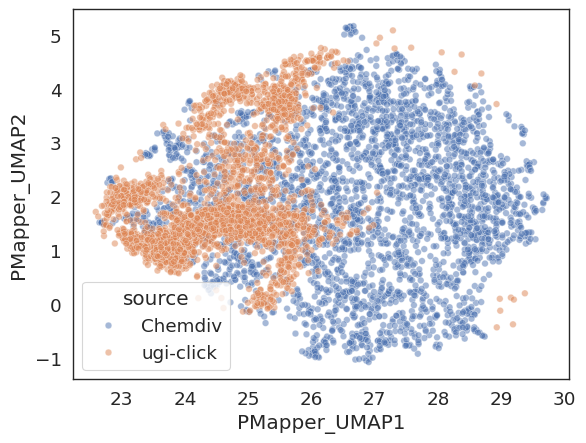

In [36]:

sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.5)
sns.scatterplot(data=df_merged, x='PMapper_UMAP1', y='PMapper_UMAP2', hue='source', alpha=0.5)

## Enamine REAL based

In [38]:
sample_num = 3000
random_seed = 1234
df_enamine_sampled = df_enamine.sample(sample_num, random_state=random_seed)

/home/zxhuang/anaconda3/envs/mollib/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


<Axes: xlabel='ECFP_UMAP1', ylabel='ECFP_UMAP2'>

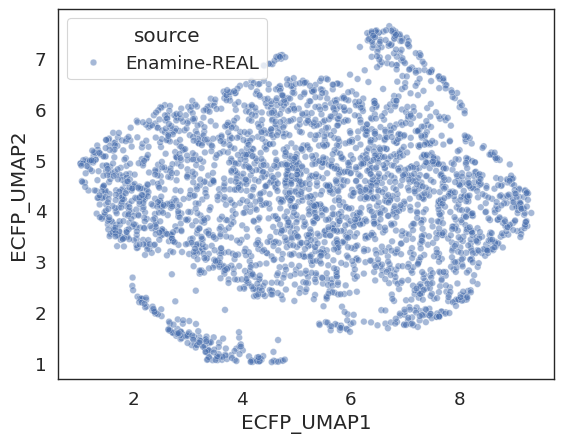

In [39]:
umap_transformer = umap.UMAP(n_components=2)
X_ecfp = ecfp_transformer(df_enamine_sampled['smiles'])
X_ecfp_umap = umap_transformer.fit_transform(X_ecfp)
df_enamine_sampled['ECFP_UMAP1'] = X_ecfp_umap[:, 0]
df_enamine_sampled['ECFP_UMAP2'] = X_ecfp_umap[:, 1]

sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.5)
sns.scatterplot(data=df_enamine_sampled, x='ECFP_UMAP1', y='ECFP_UMAP2', hue='source', alpha=0.5)

In [41]:
X_ecfp = ecfp_transformer(df_ugi_sample['smiles'])
X_ecfp_umap = umap_transformer.transform(X_ecfp)
df_ugi_sample['ECFP_UMAP1'] = X_ecfp_umap[:, 0]
df_ugi_sample['ECFP_UMAP2'] = X_ecfp_umap[:, 1]
df_merged = pd.concat([df_enamine_sampled, df_ugi_sample], ignore_index=True)

<Axes: xlabel='ECFP_UMAP1', ylabel='ECFP_UMAP2'>

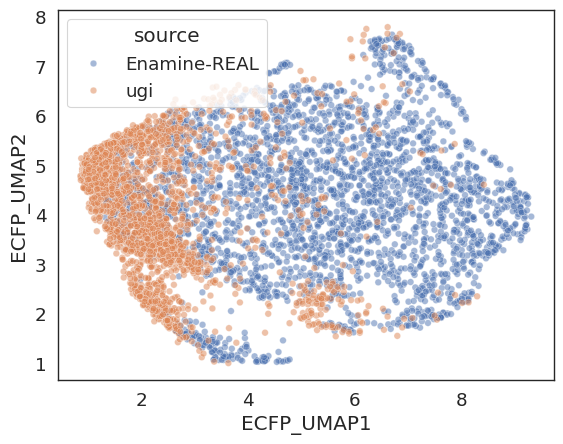

In [42]:
sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.5)
sns.scatterplot(data=df_merged, x='ECFP_UMAP1', y='ECFP_UMAP2', hue='source', alpha=0.5)

In [43]:
X_ecfp = ecfp_transformer(df_ugi_click_sample['smiles'])
X_ecfp_umap = umap_transformer.transform(X_ecfp)
df_ugi_click_sample['ECFP_UMAP1'] = X_ecfp_umap[:, 0]
df_ugi_click_sample['ECFP_UMAP2'] = X_ecfp_umap[:, 1]
df_merged = pd.concat([df_enamine_sampled, df_ugi_click_sample], ignore_index=True)

<Axes: xlabel='ECFP_UMAP1', ylabel='ECFP_UMAP2'>

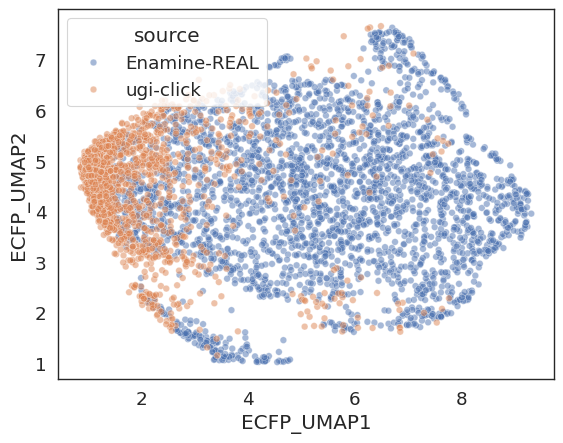

In [44]:
sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.5)
sns.scatterplot(data=df_merged, x='ECFP_UMAP1', y='ECFP_UMAP2', hue='source', alpha=0.5)

## click and ugi merged

In [51]:
sample_num = 3000
random_seed = 1234
# df_click_sampled = df_click.sample(sample_num, random_state=random_seed)
df_ugi_click_sampled = df_ugi_click_sample.sample(sample_num, random_state=random_seed)
df_ugi_sampled = df_ugi_sample.sample(sample_num, random_state=random_seed)
df_merged = pd.concat([df_ugi_sampled, df_ugi_click_sampled], ignore_index=True)
umap_transformer = umap.UMAP(n_components=2)
X_ecfp = ecfp_transformer(df_merged['smiles'])
X_ecfp_umap = umap_transformer.fit_transform(X_ecfp)
df_merged['ECFP_UMAP1'] = X_ecfp_umap[:, 0]
df_merged['ECFP_UMAP2'] = X_ecfp_umap[:, 1]

<Axes: xlabel='ECFP_UMAP1', ylabel='ECFP_UMAP2'>

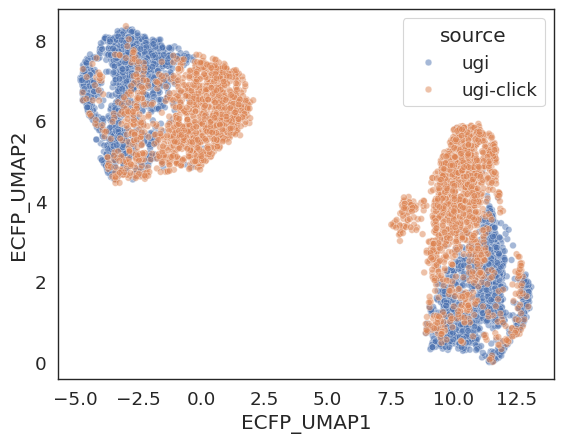

In [52]:
sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.5)
sns.scatterplot(data=df_merged, x='ECFP_UMAP1', y='ECFP_UMAP2', hue='source', alpha=0.5)

<Axes: xlabel='ECFP_TSNE1', ylabel='ECFP_TSNE2'>

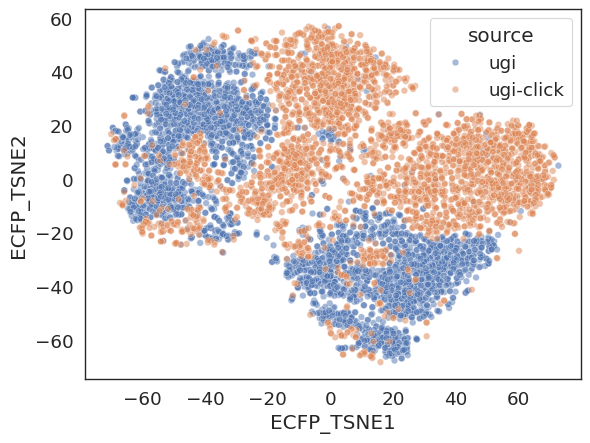

In [53]:
tsne_transformer = TSNE(n_components=2)
X_ecfp = ecfp_transformer(df_merged['smiles'])
X_ecfp_tsne = tsne_transformer.fit_transform(X_ecfp)
df_merged['ECFP_TSNE1'] = X_ecfp_tsne[:, 0]
df_merged['ECFP_TSNE2'] = X_ecfp_tsne[:, 1]

sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.5)
sns.scatterplot(data=df_merged, x='ECFP_TSNE1', y='ECFP_TSNE2', hue='source', alpha=0.5)

<Axes: xlabel='ECFP_UMAP1', ylabel='ECFP_UMAP2'>

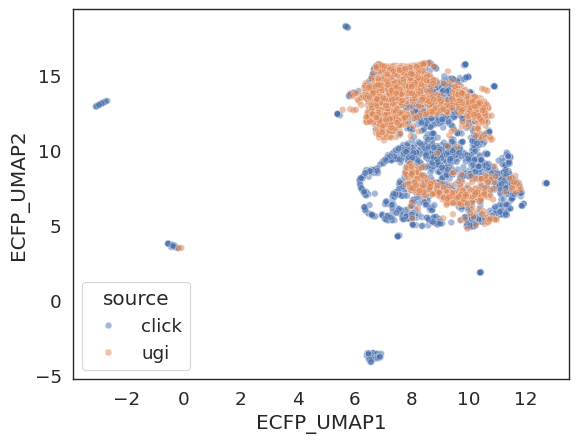

In [47]:
X_ecfp = ecfp_transformer(df_ugi_sample['smiles'])
X_ecfp_umap = umap_transformer.transform(X_ecfp)
df_ugi_sample['ECFP_UMAP1'] = X_ecfp_umap[:, 0]
df_ugi_sample['ECFP_UMAP2'] = X_ecfp_umap[:, 1]
df_merged = pd.concat([df_click_sampled, df_ugi_sample], ignore_index=True)

sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.5)
sns.scatterplot(data=df_merged, x='ECFP_UMAP1', y='ECFP_UMAP2', hue='source', alpha=0.5)

<Axes: xlabel='ECFP_UMAP1', ylabel='ECFP_UMAP2'>

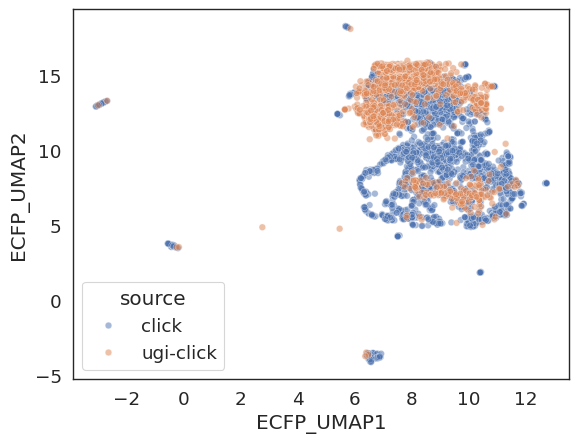

In [48]:
X_ecfp = ecfp_transformer(df_ugi_click_sample['smiles'])
X_ecfp_umap = umap_transformer.transform(X_ecfp)
df_ugi_click_sample['ECFP_UMAP1'] = X_ecfp_umap[:, 0]
df_ugi_click_sample['ECFP_UMAP2'] = X_ecfp_umap[:, 1]
df_merged = pd.concat([df_click_sampled, df_ugi_click_sample], ignore_index=True)

sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.5)
sns.scatterplot(data=df_merged, x='ECFP_UMAP1', y='ECFP_UMAP2', hue='source', alpha=0.5)

### merged

In [10]:
df_enamine_sampled = df_enamine.sample(sample_num*3)
df_chemdiv_sampled = df_chemdiv.sample(sample_num*3)
df_click_sampled = df_click.sample(sample_num*3)
df_merged = pd.concat([
    df_enamine_sampled, 
    df_chemdiv_sampled, 
    df_click_sampled, 
    # df_ugi_click_sample
    ], ignore_index=True)
df_merged

,smiles,id,source
0,CC1=CC(C)=C(C(=O)NC23CCCCC2N(C(=O)C2=NC=CC=C2O...,PV-005351855183,Enamine-REAL
1,COCC1=C(C)C=CC=C1NC(=O)C(CC(F)(F)F)NC(=O)OC(C)...,Z3585798248,Enamine-REAL
2,C#CCNC(=O)CC(=O)N1CC(NC(=O)C2=COC(C3CCC3)=N2)CC1C,PV-001125454535,Enamine-REAL
3,CCC1=C(C(=O)N[C@H]2C[C@H](C3=NC=CN3)C2)SC(N2C=...,Z4267109255,Enamine-REAL
4,CNC1=NC=CC=C1C(=O)N1CCC[C@H]1CN(C)C(=O)C1(C)CC...,PV-005319836725,Enamine-REAL
...,...,...,...
8995,NCCCCCCc1cn([C@@H](c2cccc(F)c2)C(F)(F)F)nn1,n5414-a274,click
8996,Cc1ccc2[nH]cc(CC(C(=O)O)n3cc(CCCCBr)nn3)c2c1,n4244-a536,click
8997,C[C@H](Cn1cc(-c2ccccc2-c2ccccc2)nn1)NC(=O)OCc1...,n650-a607,click
8998,CNCc1cn([C@@H](Cc2ccc(OC)cc2Cl)C(=O)O)nn1,n2785-a411,click


In [11]:
umap_transformer = umap.UMAP(n_components=2)
pca_transformer = PCA(n_components=2)
tsne_transformer = TSNE(n_components=2)

X_ecfp = ecfp_transformer(df_merged['smiles'])
print('ECFP done')
X_pca = pca_transformer.fit_transform(X_ecfp)
df_merged['ECFP4_PCA_1'] = X_pca[:, 0]
df_merged['ECFP4_PCA_2'] = X_pca[:, 1]
print('PCA done')
X_tsne = tsne_transformer.fit_transform(X_ecfp)
df_merged['ECFP4_TSNE_1'] = X_tsne[:, 0]
df_merged['ECFP4_TSNE_2'] = X_tsne[:, 1]
print('TSNE done')
X_umap = umap_transformer.fit_transform(X_ecfp)
df_merged['ECFP4_UMAP_1'] = X_umap[:, 0]
df_merged['ECFP4_UMAP_2'] = X_umap[:, 1]
print('UMAP done')

/home/zxhuang/anaconda3/envs/mollib/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


ECFP done
PCA done
TSNE done
UMAP done


<Axes: xlabel='ECFP4_UMAP_1', ylabel='ECFP4_UMAP_2'>

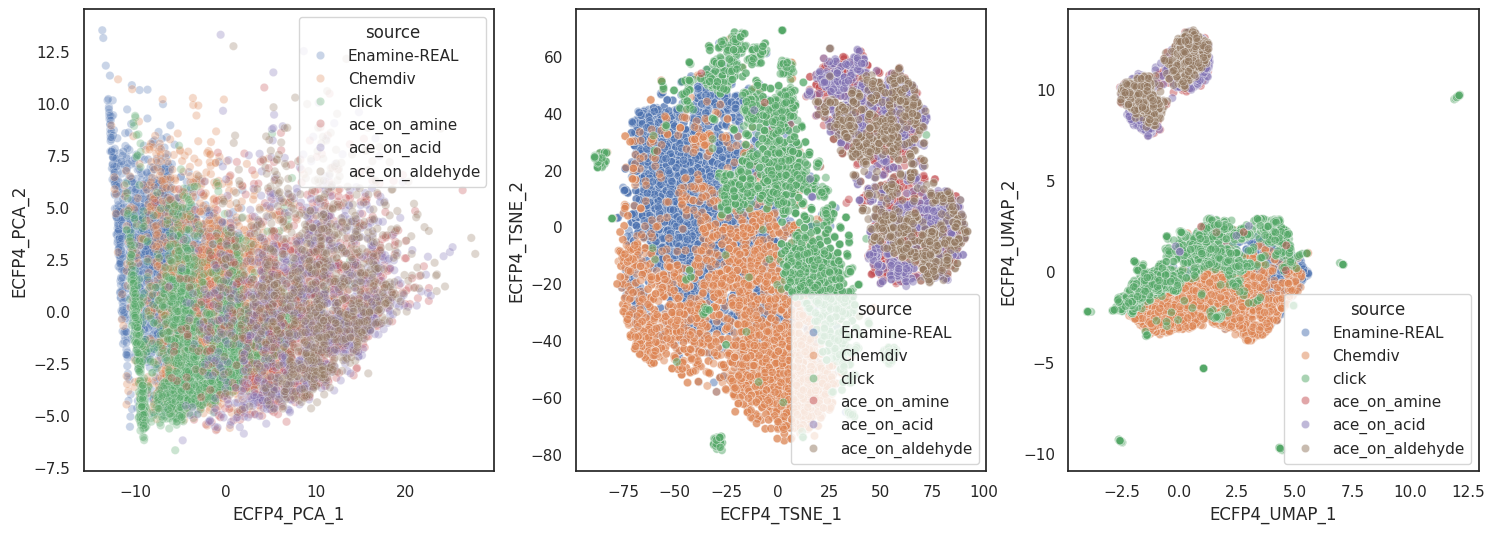

In [129]:
# ecfp 6000 samples
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.scatterplot(data=df_merged, x='ECFP4_PCA_1', y='ECFP4_PCA_2', hue='source', ax=axes[0], alpha=0.3)
sns.scatterplot(data=df_merged, x='ECFP4_TSNE_1', y='ECFP4_TSNE_2', hue='source', ax=axes[1], alpha=0.5)
sns.scatterplot(data=df_merged, x='ECFP4_UMAP_1', y='ECFP4_UMAP_2', hue='source', ax=axes[2], alpha=0.5)


<Axes: xlabel='ECFP4_TSNE_1', ylabel='ECFP4_TSNE_2'>

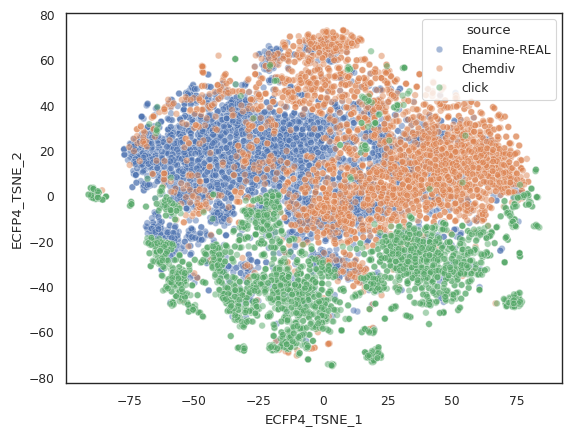

In [12]:
sns.set_theme(style="white")
sns.set_context("paper", font_scale=1)
sns.scatterplot(data=df_merged, x='ECFP4_TSNE_1', y='ECFP4_TSNE_2', hue='source', alpha=0.5)


In [109]:
df_ = df_merged[(df_merged['source'] == 'ace_on_amine') & (df_merged['ECFP4_UMAP_1'] < 5)]
df_['smiles'].tolist()

['CC(C)(C)NC(=O)C(C1=C(C(C)(C)C)NC=N1)N(CC1=CN([C@@H](CO)C2=NC=CS2)N=N1)C(=O)[C@@H]1C[C@@H](F)CN1',
 'CC1=C(O)C(C(C(=O)NCC2=CC=CC=C2)N(C(=O)C2=CC(Cl)=CC(F)=C2Cl)C2=CC=CC(C3=CN([C@H]4CCN(C(=O)OC(C)(C)C)C[C@H]4F)N=N3)=C2)=CC=C1',
 'CCC(C)(C)C1CCC(N2C=C(C3=CC(N(C(=O)C4=C(F)C=CC=C4Br)C(C(=O)NCC4=CC=CC=C4)C4=C5C=CC=CN5C=N4)=CC=C3)N=N2)CC1',
 'CN(C)CC(C(=O)NCC1=CC=CC=C1)N(C(=O)CC1=CC=C2C=CNC2=C1)C1=CC=CC(C2=CN(CC3CNC3)N=N2)=C1',
 'CC(C)C1=CC=CC=C1C(C(=O)NC(C)(C)C)N(C(=O)C1CCC2=C(C=CC=C2)O1)C1=CC=CC(C2=CN(CC3CN(CC4=CC=CC=C4)CCO3)N=N2)=C1',
 'CCC1=CC(C(C(=O)NC(C)(C)C)N(C(=O)C2=CC=CC3=CN(C)N=C23)C2=CC=CC=C2C2=CN(C[C@H]3CCC(=O)N3)N=N2)=CC=C1',
 'CC(=O)N1CCC[C@@H]1C(=O)N(C1=CC=CC(C2=CN(CC3=CCN(CC4=CC=CC=C4)CC3)N=N2)=C1)C(C(=O)NCC1=CC=CC=C1)C1=CN=C(C2=CC=CC=C2F)N=C1',
 'CC1=C(OCCN2C=C(C3=CC=CC=C3N(C(=O)C3=CC4=CC=C(Cl)C=C4N3)C(C(=O)NC(C)(C)C)C3=CC(Br)=CC(F)=C3F)N=N2)C=CC=C1',
 'CC1=NN(C)C(C)=C1C(C(=O)NCC1=CC=CC=C1)N(C(=O)C1=CC(Br)=CC2=C1NC=C2)C1=CC=CC=C1C1=CN(C(C2=C(F)C=CC(Br)=C2)C2CC2)N=N1',
 'CN1

In [110]:
X_pmapper = pmapper_transformer(df_merged['smiles'])
print('Pharm done')
X_pca = pca_transformer.fit_transform(X_pmapper)
df_merged['Pharm_PCA_1'] = X_pca[:, 0]
df_merged['Pharm_PCA_2'] = X_pca[:, 1]
print('PCA done')
X_tsne = tsne_transformer.fit_transform(X_pmapper)
df_merged['Pharm_TSNE_1'] = X_tsne[:, 0]
df_merged['Pharm_TSNE_2'] = X_tsne[:, 1]
print('TSNE done')
X_umap = umap_transformer.fit_transform(X_pmapper)
df_merged['Pharm_UMAP_1'] = X_umap[:, 0]
df_merged['Pharm_UMAP_2'] = X_umap[:, 1]
print('UMAP done')

Pharm done
PCA done
TSNE done
UMAP done


<Axes: xlabel='Pharm_TSNE_1', ylabel='Pharm_TSNE_2'>

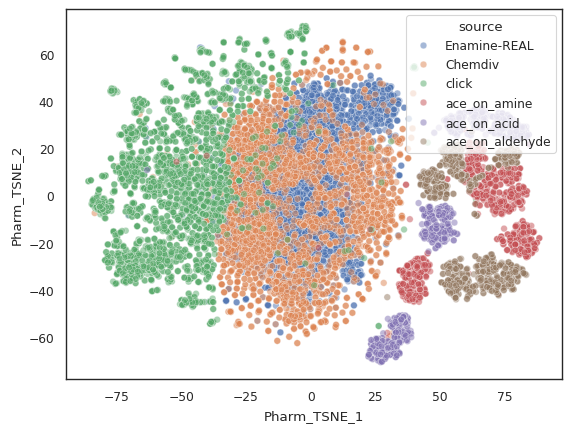

In [124]:
# pharmacophore 6000 samples
# fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# sns.scatterplot(data=df_merged, x='Pharm_PCA_1', y='Pharm_PCA_2', hue='source', ax=axes[0], alpha=0.5)
# sns.scatterplot(data=df_merged, x='Pharm_TSNE_1', y='Pharm_TSNE_2', hue='source', ax=axes[1], alpha=0.5)
# sns.scatterplot(data=df_merged, x='Pharm_UMAP_1', y='Pharm_UMAP_2', hue='source', ax=axes[2], alpha=0.5)
sns.set_theme(style="white")
sns.set_context("paper", font_scale=1)
sns.scatterplot(data=df_merged, x='Pharm_TSNE_1', y='Pharm_TSNE_2', hue='source', alpha=0.5)


<Axes: xlabel='UMAP_1', ylabel='UMAP_2'>

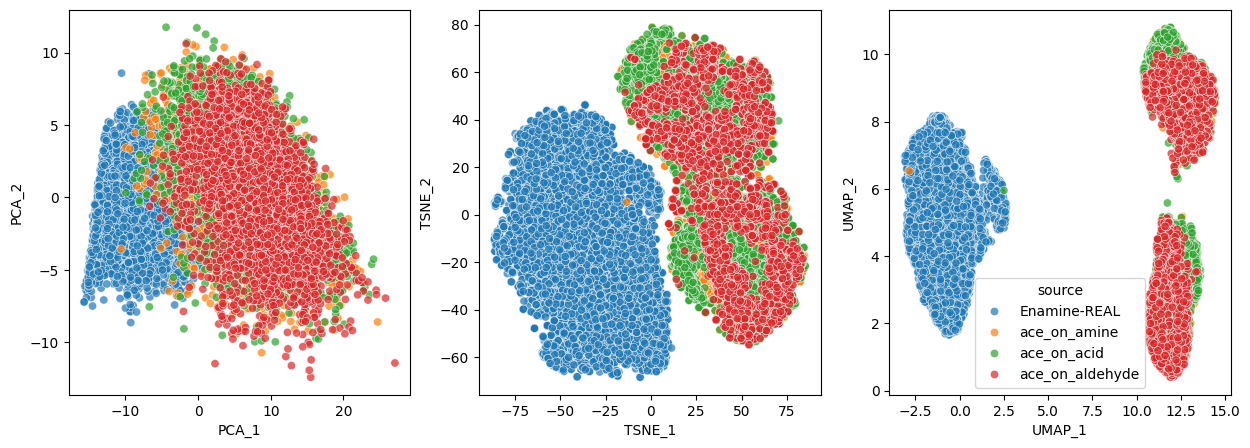

In [28]:
# ecfp 10,000 samples
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
sns.scatterplot(data=df_merged, x='PCA_1', y='PCA_2', hue='source', ax=ax[0], alpha=0.7, legend=False)
sns.scatterplot(data=df_merged, x='TSNE_1', y='TSNE_2', hue='source', ax=ax[1], alpha=0.7, legend=False)
sns.scatterplot(data=df_merged, x='UMAP_1', y='UMAP_2', hue='source', ax=ax[2], alpha=0.7, )


<Axes: xlabel='UMAP_1', ylabel='UMAP_2'>

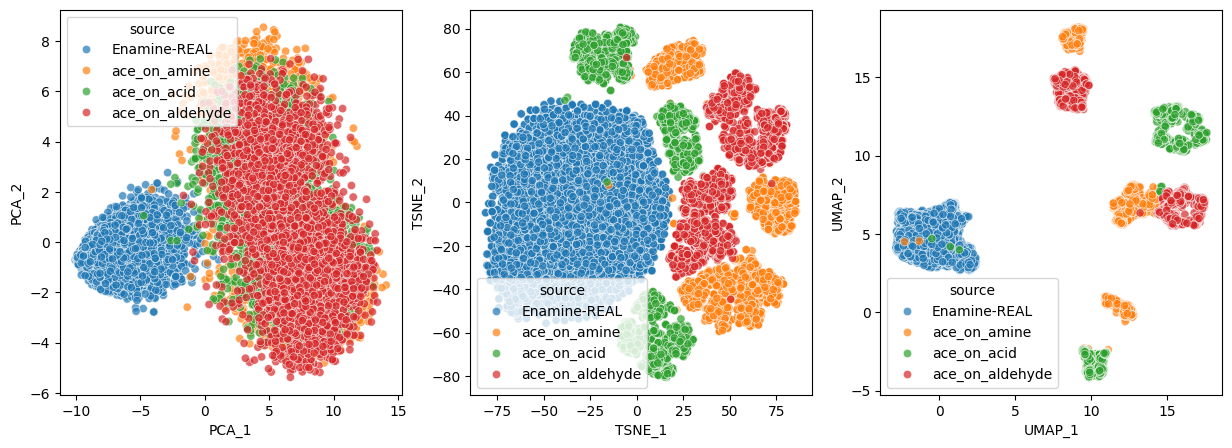

In [30]:
# pmapper 10,000 samples
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
sns.scatterplot(data=df_merged, x='PCA_1', y='PCA_2', hue='source', ax=ax[0], alpha=0.7, )
sns.scatterplot(data=df_merged, x='TSNE_1', y='TSNE_2', hue='source', ax=ax[1], alpha=0.7, )
sns.scatterplot(data=df_merged, x='UMAP_1', y='UMAP_2', hue='source', ax=ax[2], alpha=0.7, )

<Axes: xlabel='UMAP_1', ylabel='UMAP_2'>

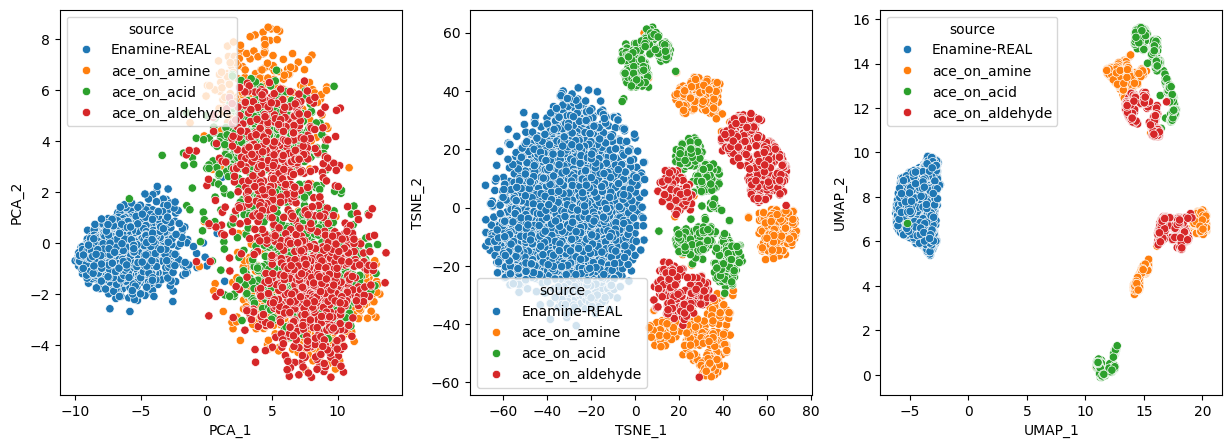

In [22]:
# pmapper 3000 samples
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
sns.scatterplot(data=df_merged, x='PCA_1', y='PCA_2', hue='source', ax=ax[0])
sns.scatterplot(data=df_merged, x='TSNE_1', y='TSNE_2', hue='source', ax=ax[1])
sns.scatterplot(data=df_merged, x='UMAP_1', y='UMAP_2', hue='source', ax=ax[2])

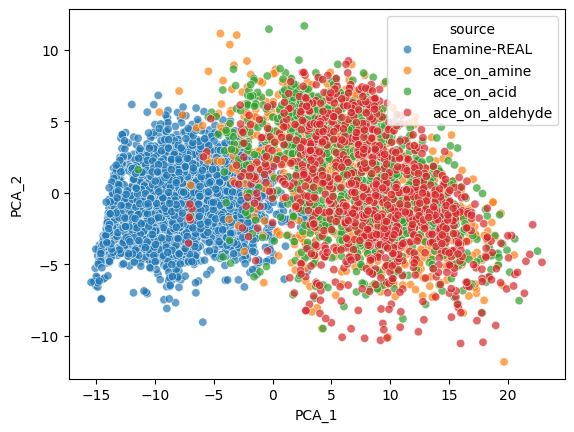

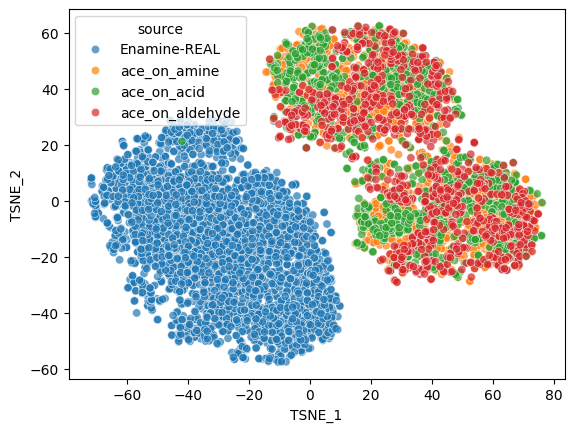

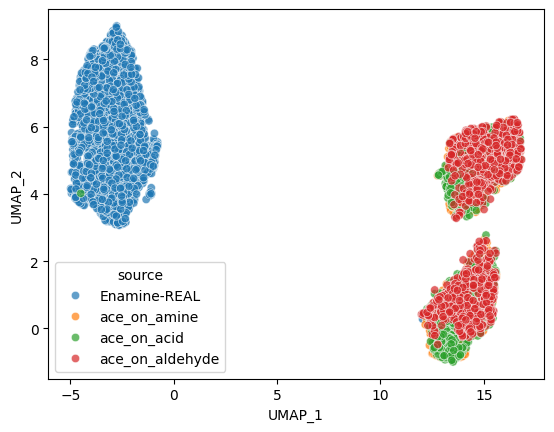

In [19]:
# ecfp 3000 samples
sns.scatterplot(data=df_merged, x='PCA_1', y='PCA_2', hue='source', alpha=0.7)
plt.show()
sns.scatterplot(data=df_merged, x='TSNE_1', y='TSNE_2', hue='source', alpha=0.7)
plt.show()
sns.scatterplot(data=df_merged, x='UMAP_1', y='UMAP_2', hue='source', alpha=0.7)
plt.show()